# Electricity Demand Forecasting — Model Report

Reproduces the production training pipeline (`jobs/elec_jobs/train/run.py`) locally and benchmarks
LightGBM against two naive baselines using **skore** `EstimatorReport` / `ComparisonReport`.

**Baselines**
- `Lag 24h` — predict yesterday's consumption at the same hour (naive daily persistence)
- `Lag 168h` — predict last week's consumption at the same hour (naive weekly persistence)

**Target**: `consommation` at T+24h, given features at T (matches production lag alignment).

## 1. Setup

In [24]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import lightgbm as lgb
import xgboost as xgb
from google.cloud import bigquery
from sklearn.base import BaseEstimator, RegressorMixin
from dotenv import load_dotenv

from skore import EstimatorReport, ComparisonReport

load_dotenv(dotenv_path="../.env")

True

## 2. Constants (mirrors `train/run.py`)

In [2]:
GCP_PROJECT_ID = os.environ["GCP_PROJECT_ID"]

# Fixed sorted region list — must stay consistent with production
REGION_CATEGORIES: list[str] = sorted([
    "Auvergne-Rhône-Alpes",
    "Bourgogne-Franche-Comté",
    "Bretagne",
    "Centre-Val de Loire",
    "Grand Est",
    "Hauts-de-France",
    "Ile-de-France",
    "Normandie",
    "Nouvelle-Aquitaine",
    "Occitanie",
    "Pays de la Loire",
    "Provence-Alpes-Côte d'Azur",
])

FEATURE_COLS = [
    "region",
    "consommation_lag_24h",
    "consommation_lag_48h",
    "consommation_lag_168h",
    "consommation_rolling_168h",
    "temperature_celsius",
    "wind_speed_kmh",
    "solar_radiation_wm2",
    "hour_of_day",
    "day_of_week",
    "is_weekend",
    "is_public_holiday_fr",
    "month",
]
TARGET_COL     = "consommation"
VAL_FRACTION   = 0.2   # last 20% of time range → validation set
TRAIN_LOOKBACK_DAYS = 730  # 2-year window

# region is at index 0 in FEATURE_COLS — used by LGBMRegressor categorical_feature
REGION_IDX = FEATURE_COLS.index("region")

## 3. Load data from BigQuery

In [3]:
client = bigquery.Client(project=GCP_PROJECT_ID)

feature_cols_sql = ", ".join(f"f.{c}" for c in FEATURE_COLS)
sql = f"""
SELECT
    f.date_heure,
    {feature_cols_sql},
    e.consommation AS {TARGET_COL}
FROM `{GCP_PROJECT_ID}.elec_features.features` AS f
JOIN `{GCP_PROJECT_ID}.elec_raw.eco2mix` AS e
    ON  e.region     = f.region
    AND e.date_heure = TIMESTAMP_ADD(f.date_heure, INTERVAL 24 HOUR)
WHERE
    f.date_heure >= TIMESTAMP_SUB(CURRENT_TIMESTAMP(), INTERVAL {TRAIN_LOOKBACK_DAYS} DAY)
    AND f.consommation_lag_24h  IS NOT NULL
    AND f.consommation_lag_168h IS NOT NULL
    AND e.consommation IS NOT NULL
ORDER BY f.date_heure
"""

df = client.query(sql).to_dataframe()
print(f"Loaded {len(df):,} rows — {df['date_heure'].min()} → {df['date_heure'].max()}")
df.head()

Loaded 648,793 rows — 2024-03-08 21:00:00+00:00 → 2026-03-07 20:00:00+00:00


,date_heure,region,consommation_lag_24h,consommation_lag_48h,consommation_lag_168h,consommation_rolling_168h,temperature_celsius,wind_speed_kmh,solar_radiation_wm2,hour_of_day,day_of_week,is_weekend,is_public_holiday_fr,month,consommation
0,2024-03-08 21:00:00+00:00,Centre-Val de Loire,2268.0,2311.0,2399.0,2385.107143,7.8,23.8,0.0,22,4,False,False,3,2163.0
1,2024-03-08 21:00:00+00:00,Bourgogne-Franche-Comté,2648.0,2638.0,2652.0,2523.961310,6.8,13.1,0.0,22,4,False,False,3,2193.0
2,2024-03-08 21:00:00+00:00,Bretagne,2805.0,2895.0,3225.0,3021.098214,7.2,17.1,0.0,22,4,False,False,3,2711.0
3,2024-03-08 21:00:00+00:00,Pays de la Loire,3174.0,3189.0,3419.0,3530.723214,7.8,11.5,0.0,22,4,False,False,3,3122.0
4,2024-03-08 21:00:00+00:00,Normandie,3475.0,3563.0,3733.0,3571.869048,9.1,16.6,0.0,22,4,False,False,3,3278.0


## 4. Preprocessing

In [25]:
# Bool → int (matches train/run.py)
for col in ("is_weekend", "is_public_holiday_fr"):
    df[col] = df[col].astype(int)

# region: fixed-order Categorical so LightGBM gets consistent label encoding
df["region"] = pd.Categorical(df["region"], categories=REGION_CATEGORIES)

# Time-based split: last VAL_FRACTION of time range → validation
dt_min, dt_max = df["date_heure"].min(), df["date_heure"].max()
cutoff = dt_min + (dt_max - dt_min) * (1 - VAL_FRACTION)
train_df = df[df["date_heure"] <= cutoff].copy()
val_df   = df[df["date_heure"] >  cutoff].copy()

print(f"Train: {len(train_df):,} rows  ({train_df['date_heure'].min().date()} → {train_df['date_heure'].max().date()})")
print(f"Val:   {len(val_df):,} rows  ({val_df['date_heure'].min().date()} → {val_df['date_heure'].max().date()})")

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]
X_val   = val_df[FEATURE_COLS]
y_val   = val_df[TARGET_COL]

Train: 481,064 rows  (2024-03-08 → 2025-10-13)
Val:   167,729 rows  (2025-10-13 → 2026-03-07)


## 5. Define estimators

In [26]:
class LagBaseline(BaseEstimator, RegressorMixin):
    """Naive baseline: predict consommation = value of a given lag column."""

    def __init__(self, lag_col: str):
        self.lag_col = lag_col

    def fit(self, X, y):
        return self  # stateless

    def predict(self, X):
        return X[self.lag_col].to_numpy()


class ElecLGBM(lgb.LGBMRegressor):
    """LGBMRegressor that enforces categorical_feature for the region column."""

    def fit(self, X, y, **kwargs):
        col_idx = list(X.columns).index("region")
        return super().fit(X, y, categorical_feature=[col_idx], **kwargs)


# XGBoost natively supports pd.Categorical with tree_method="hist" + enable_categorical=True
ElecXGB = xgb.XGBRegressor

lgbm = ElecLGBM(
    objective="regression",
    metric="mae",
    num_leaves=63,
    learning_rate=0.05,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    n_estimators=500,
    verbose=-1,
)

xgbm = ElecXGB(
    objective="reg:absoluteerror",
    tree_method="hist",
    enable_categorical=True,
    max_leaves=63,
    learning_rate=0.05,
    colsample_bytree=0.8,
    subsample=0.8,
    n_estimators=500,
    verbosity=0,
)

lag_24h  = LagBaseline("consommation_lag_24h")
lag_168h = LagBaseline("consommation_lag_168h")

## 6. skore EstimatorReports

Each report fits the estimator on `X_train / y_train` and evaluates on `X_val / y_val`.

In [27]:
report_lgbm = EstimatorReport(
    lgbm,
    X_train=X_train, y_train=y_train,
    X_test=X_val,   y_test=y_val,
)
print("LightGBM report ready")

LightGBM report ready


In [28]:
report_xgbm = EstimatorReport(
    xgbm,
    X_train=X_train, y_train=y_train,
    X_test=X_val,   y_test=y_val,
)
print("XGBoost report ready")

XGBoost report ready


In [29]:
report_lag24 = EstimatorReport(
    lag_24h,
    X_train=X_train, y_train=y_train,
    X_test=X_val,   y_test=y_val,
)
print("Lag 24h baseline ready")

Lag 24h baseline ready


In [30]:
report_lag168 = EstimatorReport(
    lag_168h,
    X_train=X_train, y_train=y_train,
    X_test=X_val,   y_test=y_val,
)
print("Lag 168h baseline ready")

Lag 168h baseline ready


## 7. Individual reports

In [31]:
print("=== LightGBM ===")
report_lgbm.metrics.summarize().frame()

=== LightGBM ===


,ElecLGBM
Metric,
R²,0.901517
RMSE,705.205864
Fit time (s),14.661231
Predict time (s),3.818769


In [32]:
print("=== XGBoost ===")
report_xgbm.metrics.summarize().frame()

=== XGBoost ===


,XGBRegressor
Metric,
R²,0.899709
RMSE,711.648633
Fit time (s),94.020830
Predict time (s),1.752087


In [33]:
print("=== Lag 24h baseline ===")
report_lag24.metrics.summarize().frame()

=== Lag 24h baseline ===


,LagBaseline
Metric,
R²,0.802883
RMSE,997.690839
Fit time (s),0.000002
Predict time (s),0.000069


In [34]:
print("=== Lag 168h baseline ===")
report_lag168.metrics.summarize().frame()

=== Lag 168h baseline ===


,LagBaseline
Metric,
R²,0.754762
RMSE,1112.829142
Fit time (s),0.000002
Predict time (s),0.000080


## 8. ComparisonReport

`ComparisonReport` goes beyond a metrics table: it produces **side-by-side plots** across all models
on the same test set, making it easy to compare prediction quality, residual patterns, and feature
reliance at a glance.

In [36]:
comparison = ComparisonReport(
    reports={
        "LightGBM": report_lgbm,
        "XGBoost":  report_xgbm,
        "Lag 24h":  report_lag24,
        "Lag 168h": report_lag168,
    }
)

### 8.1 Metrics summary with favorability

`favorability=True` highlights the best model per metric — green = better, red = worse.

In [37]:
comparison.metrics.summarize(favorability=True).frame()

Output()

Estimator,LightGBM,XGBoost,Lag 24h,Lag 168h,Favorability
Metric,,,,,
R²,0.901517,0.899709,0.802883,0.754762,(↗︎)
RMSE,705.205864,711.648633,997.690839,1112.829142,(↘︎)
Fit time (s),14.661231,94.020830,0.000002,0.000002,(↘︎)
Predict time (s),3.818769,1.752087,0.000069,0.000080,(↘︎)


### 8.2 Actual vs predicted

The diagonal line is the perfect model. Points closer to the diagonal = better predictions.
Baselines show the characteristic fan-shape of a weak model at high demand levels.

Output()

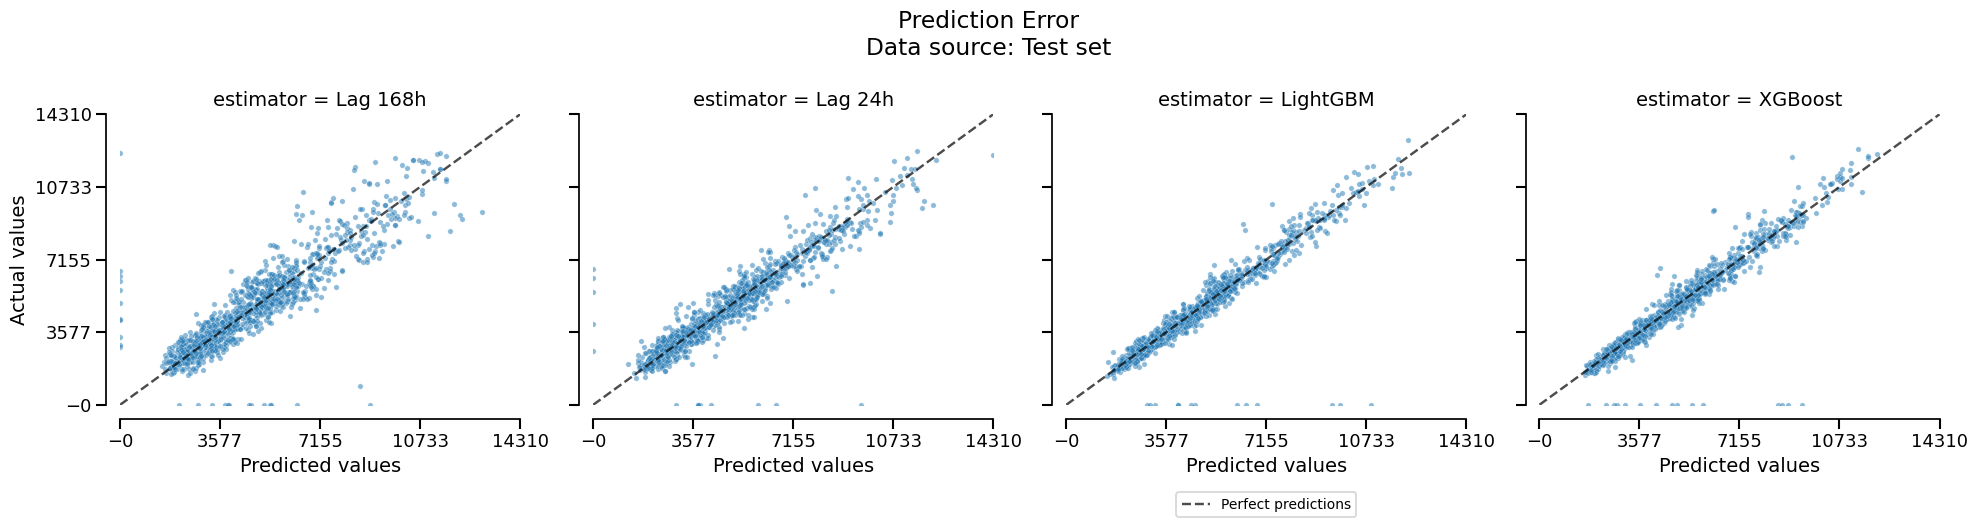

In [42]:
comparison.metrics.prediction_error(
    subsample=5_000, seed=42
).plot(subplot_by="estimator", kind="actual_vs_predicted")

### 8.3 Residuals vs predicted

Residuals should be centered around 0 with no structure. Patterns (e.g. residuals growing with
predicted value) indicate systematic bias the model hasn't captured.

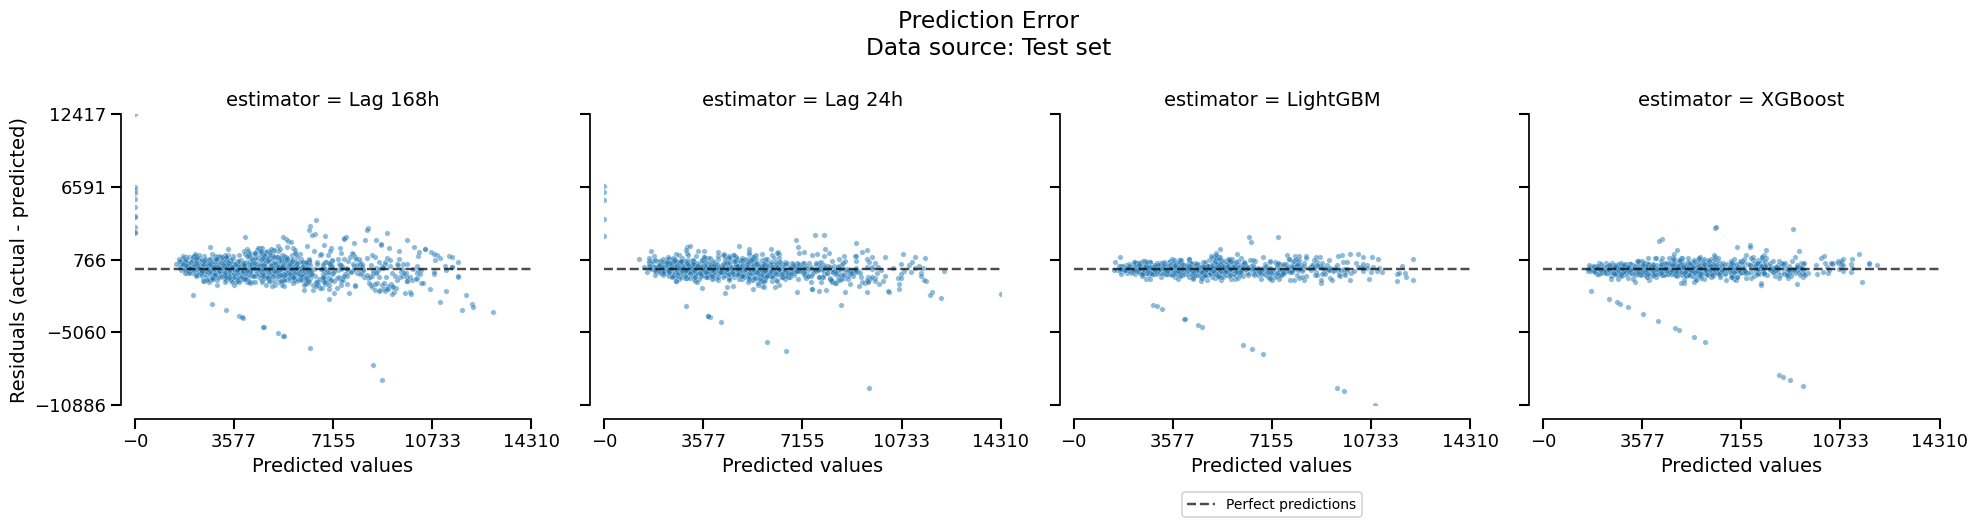

In [43]:
comparison.metrics.prediction_error(
    subsample=5_000, seed=42
).plot(subplot_by="estimator", kind="residual_vs_predicted")

### 8.4 Fit & predict timings

Speed matters in production. LightGBM and XGBoost are compared on both training and inference cost.

In [40]:
comparison.metrics.timings()

,LightGBM,XGBoost,Lag 24h,Lag 168h
Fit time (s),14.661231,94.020830,0.000002,0.000002
Predict time test (s),3.818769,1.752087,0.000069,0.000080


### 8.5 Permutation importance (ML models)

Which features does each model actually rely on? We compare LightGBM vs XGBoost on the same test
set. `max_samples=0.05` keeps this fast on 167k rows.

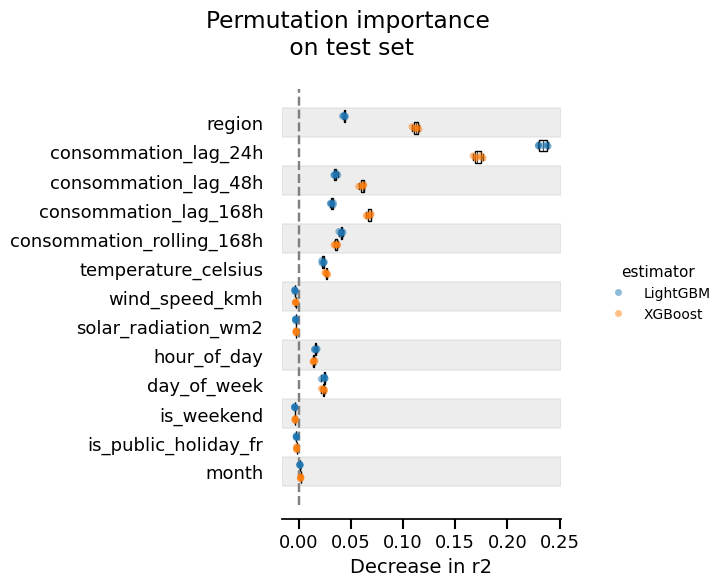

In [41]:
# Restrict to ML models only — baselines are single-feature and skew the scale
ml_comparison = ComparisonReport(
    reports={"LightGBM": report_lgbm, "XGBoost": report_xgbm}
)
ml_comparison.inspection.permutation_importance(
    n_repeats=5, max_samples=0.05, seed=42
).plot()

## 9. Feature importances

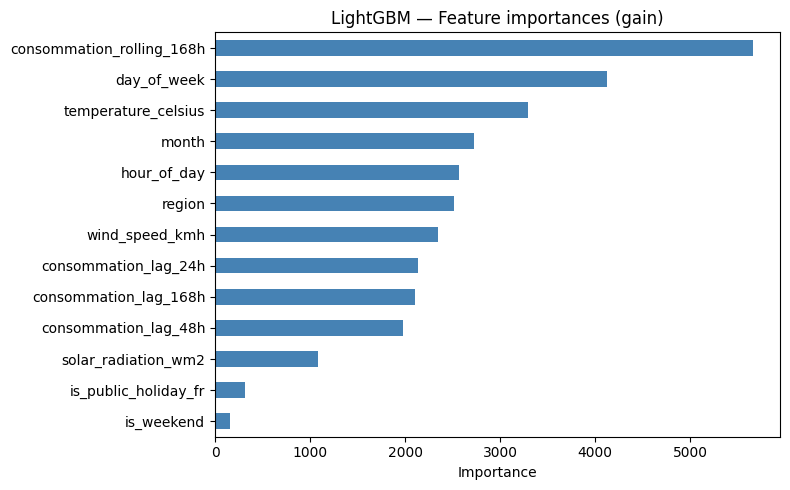

In [14]:
import matplotlib.pyplot as plt

booster = report_lgbm.estimator_  # fitted estimator
fi = pd.Series(
    booster.feature_importances_,
    index=FEATURE_COLS,
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
fi.plot.barh(ax=ax, color="steelblue")
ax.set_title("LightGBM — Feature importances (gain)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## 10. Residuals by region

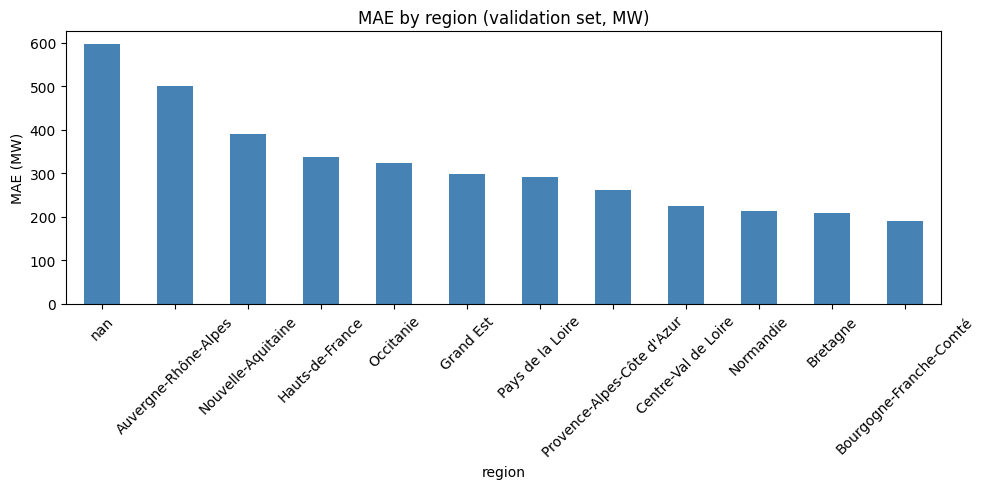

In [15]:
preds = booster.predict(X_val)
residuals = pd.DataFrame({
    "region":   val_df["region"].astype(str),
    "actual":   y_val.values,
    "predicted": preds,
    "error":    np.abs(y_val.values - preds),
})

mae_by_region = residuals.groupby("region")["error"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
mae_by_region.plot.bar(ax=ax, color="steelblue")
ax.set_title("MAE by region (validation set, MW)")
ax.set_ylabel("MAE (MW)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()